# Customer Data Cleaning Project

A structured data cleaning pipeline applied to an Iranian market customer dataset,
covering demographic and purchasing behavior records.

## Project Overview

This project performs end-to-end data cleaning on a raw customer dataset (61 records, 17 features),
preparing it for downstream analysis by resolving quality issues across data types,
missing values, duplicates, and categorical inconsistencies.

## Dataset

The dataset contains customer profiles from the Iranian market, including:
- Demographics: name, gender, age, city, province
- Membership: registration date, membership tier (Bronze → Silver → Gold → VIP)
- Purchase behavior: purchase count, average order value, total spending, days since last purchase
- Interaction data: payment method, device, discount usage, return items, satisfaction score

## Cleaning Steps

1. **Type Conversion** — Parsed `signup_date` from `object` to `datetime64`; cast `purchase_count` to `int64`; converted categorical columns (`gender`, `city`, `province`, `payment_method`, `device`, `discount_used`, `satisfaction_score`) to `category` dtype.
2. **Missing Value Treatment** — Identified 1.64% missingness in `age` and `total_spending`; imputed `age` with column median.
3. **Duplicate Removal** — Detected and removed duplicate `customer_id` (ID: 1014), retaining the first occurrence.
4. **Gender Consistency Fix** — Built a name-to-gender mapping; corrected 38 mismatched gender entries based on first name.
5. **Outlier Correction** — Replaced unrealistic age value (145 → 45).
6. **Ordinal Encoding** — Defined explicit membership tier ordering for proper categorical analysis.

## Author

**Mohammad Kaboli**  
Master's Student in Data Analysis  
📧 Contact: `M.kaboli02181@gmail.com`

---
*Tools: Python · Pandas · Jupyter Notebook*


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [71]:
df = pd.read_excel("First Dataset.xlsx")
df["signup_date"] = pd.to_datetime(df["signup_date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   customer_id         61 non-null     int64         
 1   first_name          61 non-null     object        
 2   gender              61 non-null     object        
 3   age                 60 non-null     float64       
 4   city                61 non-null     object        
 5   province            61 non-null     object        
 6   signup_date         61 non-null     datetime64[ns]
 7   membership_tier     61 non-null     object        
 8   purchase_count      61 non-null     int64         
 9   avg_order_value     61 non-null     float64       
 10  total_spending      60 non-null     float64       
 11  last_purchase_days  61 non-null     int64         
 12  payment_method      61 non-null     object        
 13  device              61 non-null     object        
 

In [5]:
df.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [8]:
print(df.isnull().sum())

customer_id           0
first_name            0
gender                0
age                   1
city                  0
province              0
signup_date           0
membership_tier       0
purchase_count        0
avg_order_value       0
total_spending        1
last_purchase_days    0
payment_method        0
device                0
discount_used         0
returned_items        0
satisfaction_score    0
dtype: int64


In [10]:
print(f"\nMissing %:\n{(df.isnull().sum()/len(df)*100).round(2)}")


Missing %:
customer_id           0.00
first_name            0.00
gender                0.00
age                   1.64
city                  0.00
province              0.00
signup_date           0.00
membership_tier       0.00
purchase_count        0.00
avg_order_value       0.00
total_spending        1.64
last_purchase_days    0.00
payment_method        0.00
device                0.00
discount_used         0.00
returned_items        0.00
satisfaction_score    0.00
dtype: float64


In [13]:
dupes = df[df.duplicated(subset="customer_id", keep=False)]
print("Duplicate IDs:\n", dupes[["customer_id", "first_name", "gender"]])
df = df.drop_duplicates(subset="customer_id", keep="first").reset_index(drop=True)

Duplicate IDs:
     customer_id first_name gender
13         1014       Reza      M
60         1014       Reza      M


In [73]:
name_variants = df["first_name"].unique()
print("Unique names:", sorted(name_variants))

Unique names: ['Ali', 'Amir', 'Arash', 'Kimia', 'Maryam', 'Mina', 'Neda', 'Parsa', 'Reza', 'Sara', 'Sina', 'Zahra']


In [17]:
gender_check = {
    'Ali': 'M', 'Amir': 'M', 'Arash': 'M', 'Kimia': 'F', 'Maryam': 'F',
    'Mina': 'F', 'Neda': 'F', 'Parsa': 'M', 'Reza': 'M', 'Sara': 'F',
    'Sina': 'M', 'Zahra': 'F'
}


mismatches = df[df["gender"] != df["first_name"].map(gender_check)]
print(f"Rows to be corrected: {len(mismatches)}")

Rows to be corrected: 38


In [19]:
df["gender"] = df["first_name"].map(gender_check)

In [21]:
print("3 youngest:", sorted(df["age"].dropna())[:3])
print("3 oldest:", sorted(df["age"].dropna())[-3:])

3 youngest: [19.0, 19.0, 22.0]
3 oldest: [64.0, 65.0, 145.0]


In [23]:
df.loc[df["age"] == 145, "age"] = 45

In [67]:
df["age"] = df["age"].fillna(df["age"].median())

In [25]:
print("Cities:", df["city"].unique())
print("Provinces:", df["province"].unique())

Cities: ['Karaj' 'Tehran' 'Shiraz' 'Mashhad' 'Isfahan' 'Rasht' 'Tabriz' 'Ahvaz']
Provinces: ['Alborz' 'Tehran' 'Fars' 'Khorasan' 'Isfahan' 'Gilan' 'East Azerbaijan'
 'Khuzestan']


In [27]:
df["gender"] = df["gender"].astype("category")
df["city"] = df["city"].astype("category")
df["province"] = df["province"].astype("category")
df["payment_method"] = df["payment_method"].astype("category")
df["device"] = df["device"].astype("category")
df["discount_used"] = df["discount_used"].astype("category")
df["satisfaction_score"] = df["satisfaction_score"].astype("category")

In [29]:
df["signup_date"] = pd.to_datetime(df["signup_date"])

tier_order = ["Bronze", "Silver", "Gold", "VIP"]
df["membership_tier"] = pd.Categorical(
    df["membership_tier"], categories=tier_order, ordered=True
)

df["purchase_count"] = df["purchase_count"].astype("int64")

In [79]:
df.dtypes

customer_id                    int64
first_name                    object
gender                      category
age                          float64
city                        category
province                    category
signup_date           datetime64[ns]
membership_tier               object
purchase_count                 int64
avg_order_value              float64
total_spending               float64
last_purchase_days             int64
payment_method              category
device                      category
discount_used               category
returned_items                 int64
satisfaction_score          category
dtype: object

In [63]:
consistency_check = df.groupby("membership_tier", observed=False).agg(
    records=("customer_id", "count"),
    avg_purchase_count=("purchase_count", "mean"),
    avg_total_spending=("total_spending", "mean")
).round(3)

print(consistency_check)
print('\n----')


outliers = df[
    ((df["membership_tier"] == "VIP") & (df["total_spending"] < df["total_spending"].quantile(0.25))) |
    ((df["membership_tier"] == "Bronze") & (df["total_spending"] > df["total_spending"].quantile(0.75)))
]
print(outliers[["customer_id", "membership_tier", "purchase_count", "total_spending"]])


                 records  avg_purchase_count  avg_total_spending
membership_tier                                                 
Bronze                18              16.889            3277.610
Silver                 8              16.500            4179.926
Gold                  19              17.053            3955.432
VIP                   15              18.867            3820.945
Purchase count monotonic across tiers: False
Total spending monotonic across tiers: False
    customer_id membership_tier  purchase_count  total_spending
24         1025             VIP               2          812.06
34         1035          Bronze              17         5918.21
35         1036             VIP               9         1040.40
42         1043             VIP              23         1035.00
49         1050          Bronze              30         6198.00
50         1051             VIP              15          997.95
54         1055          Bronze              19         6068.22
56      

In [69]:
df["total_spending"] = df.groupby("membership_tier", observed=False)["total_spending"].transform(
    lambda x: x.fillna(x.median())
)

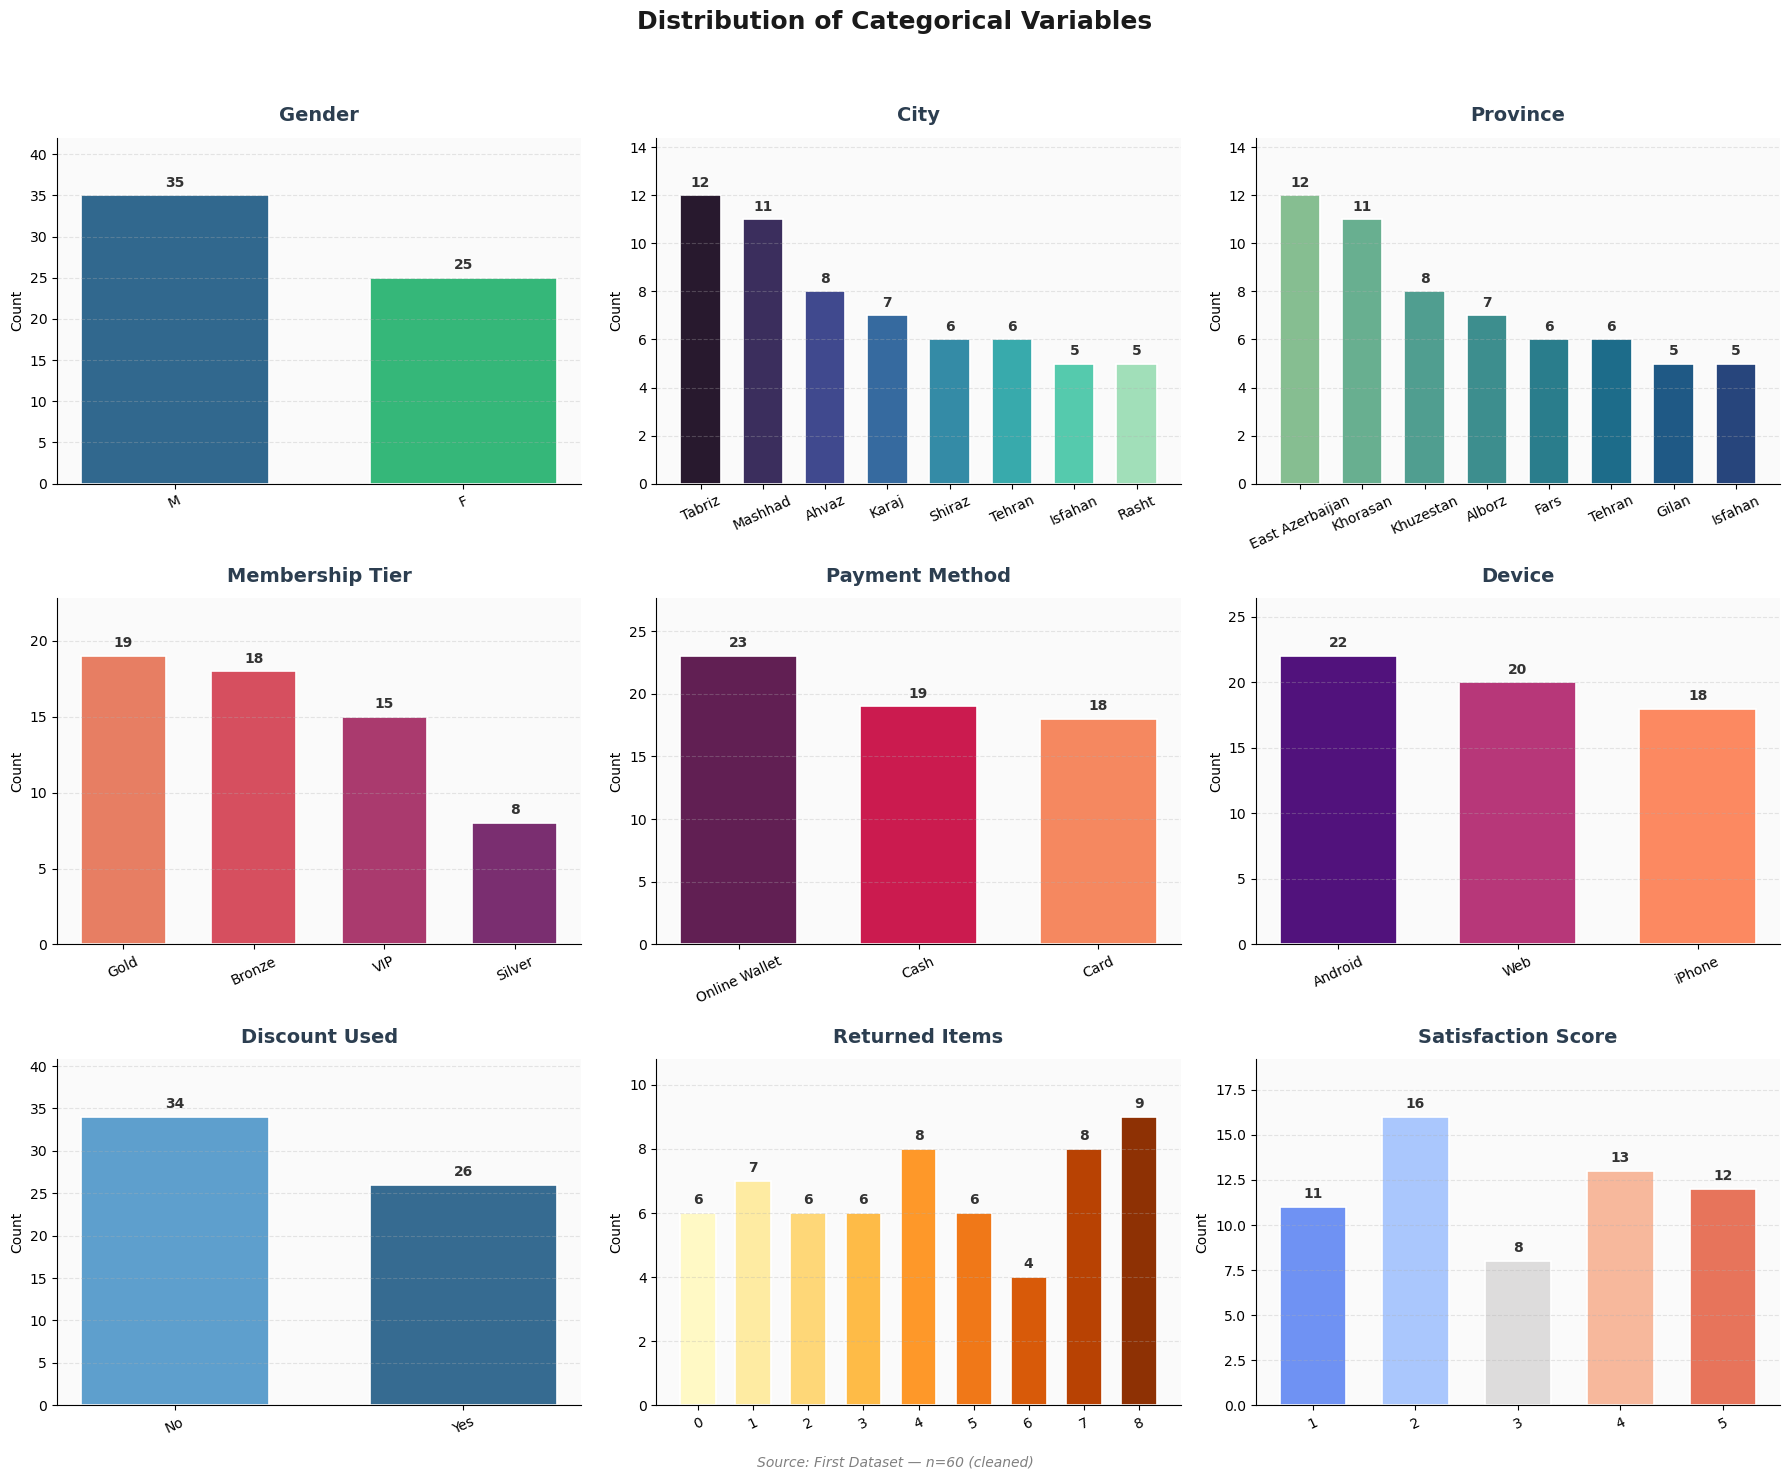

In [49]:
cat_cols = ['gender', 'city', 'province', 'membership_tier',
            'payment_method', 'device', 'discount_used', 'returned_items', 'satisfaction_score']

palettes = ['viridis', 'mako', 'crest', 'flare', 'rocket', 'magma', 'Blues_d', 'YlOrBr', 'coolwarm']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, (col, pal) in enumerate(zip(cat_cols, palettes)):
    counts = df[col].value_counts()
    if col in ['returned_items', 'satisfaction_score']:
        counts = counts.sort_index()
    else:
        counts = counts.sort_values(ascending=False)
    
    colors = sns.color_palette(pal, len(counts))
    bars = axes[i].bar(counts.index.astype(str), counts.values,
                       color=colors, edgecolor='white', linewidth=1.2, width=0.65)
    
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, val + max(counts.values)*0.02,
                     f'{val}', ha='center', va='bottom',
                     fontsize=10, fontweight='bold', color='#333333')
    
    axes[i].set_title(col.replace('_', ' ').title(),
                      fontsize=14, fontweight='bold', color='#2c3e50', pad=12)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=25, labelsize=10)
    axes[i].set_ylim(0, max(counts.values) * 1.2)
    sns.despine(ax=axes[i])
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')
    axes[i].set_facecolor('#fafafa')

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribution of Categorical Variables',
             fontsize=18, fontweight='bold', color='#1a1a1a', y=1.03)
fig.text(0.5, -0.01, 'Source: First Dataset — n=60 (cleaned)',
         ha='center', fontsize=10, style='italic', color='gray')

plt.tight_layout()
plt.savefig('categorical_bar_charts_pro.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


## 📊 Categorical Variables Distribution — Analysis (n=60)

### Gender
Males (35) slightly outnumber females (25), a ~58% to 42% split. Given the small sample size (n=60), this gap is not necessarily structural — as the customer base grows, we expect this ratio to converge toward a more random (closer to 50/50) distribution, assuming no strong gender-based targeting in acquisition channels.

### City & Province
Tabriz (12) and Mashhad (11) are currently our primary hubs, with East Azerbaijan and Khorasan leading at the province level — consistent with the city-level data. However, the relatively flat shape of the distribution across other cities suggests this concentration may be more a byproduct of current business focus (marketing, logistics, partnerships) than an inherent customer preference. A shift in business focus could plausibly yield a more even, near-random distribution across provinces going forward.

### Membership Tier
Gold (19) is the largest segment, followed by Bronze (18), VIP (15), and Silver (8) as the smallest. The underrepresentation of Silver may indicate a gap in the loyalty program's mid-tier value proposition.

### Payment Method
Online Wallet (23) is the dominant payment method, with Cash (19) and Card (18) fairly close behind.

### Device
Usage is fairly balanced across Android (22), Web (20), and iPhone (18), with a slight lean toward Android.

### Discount Usage
The majority of customers (34, 57%) did not use a discount, versus 26 (43%) who did.

### Returned Items
Fairly uniform distribution from 0 to 8 returns, with the highest frequency at 8 returns (9 customers) — notably, return counts of 4+ occur frequently across the dataset.

### Satisfaction Score
The score distribution is skewed toward the lower end (mode at 2, dip at 3). Grouping scores into **Satisfied (4–5)** vs. **Dissatisfied (1–2)** shows that the dissatisfied group makes up the majority of customers. This pattern, combined with the high frequency of returns at 4+ items, points to a consistent signal: **product/service quality appears unacceptable to a significant portion of our customer base**, and returns are likely a direct behavioral consequence of that dissatisfaction rather than an isolated issue.

> **Key Insight:** The alignment between low satisfaction scores and high return counts (≥4) strongly suggests a quality control problem that should be prioritized in root-cause analysis, rather than treating returns and satisfaction as independent metrics.


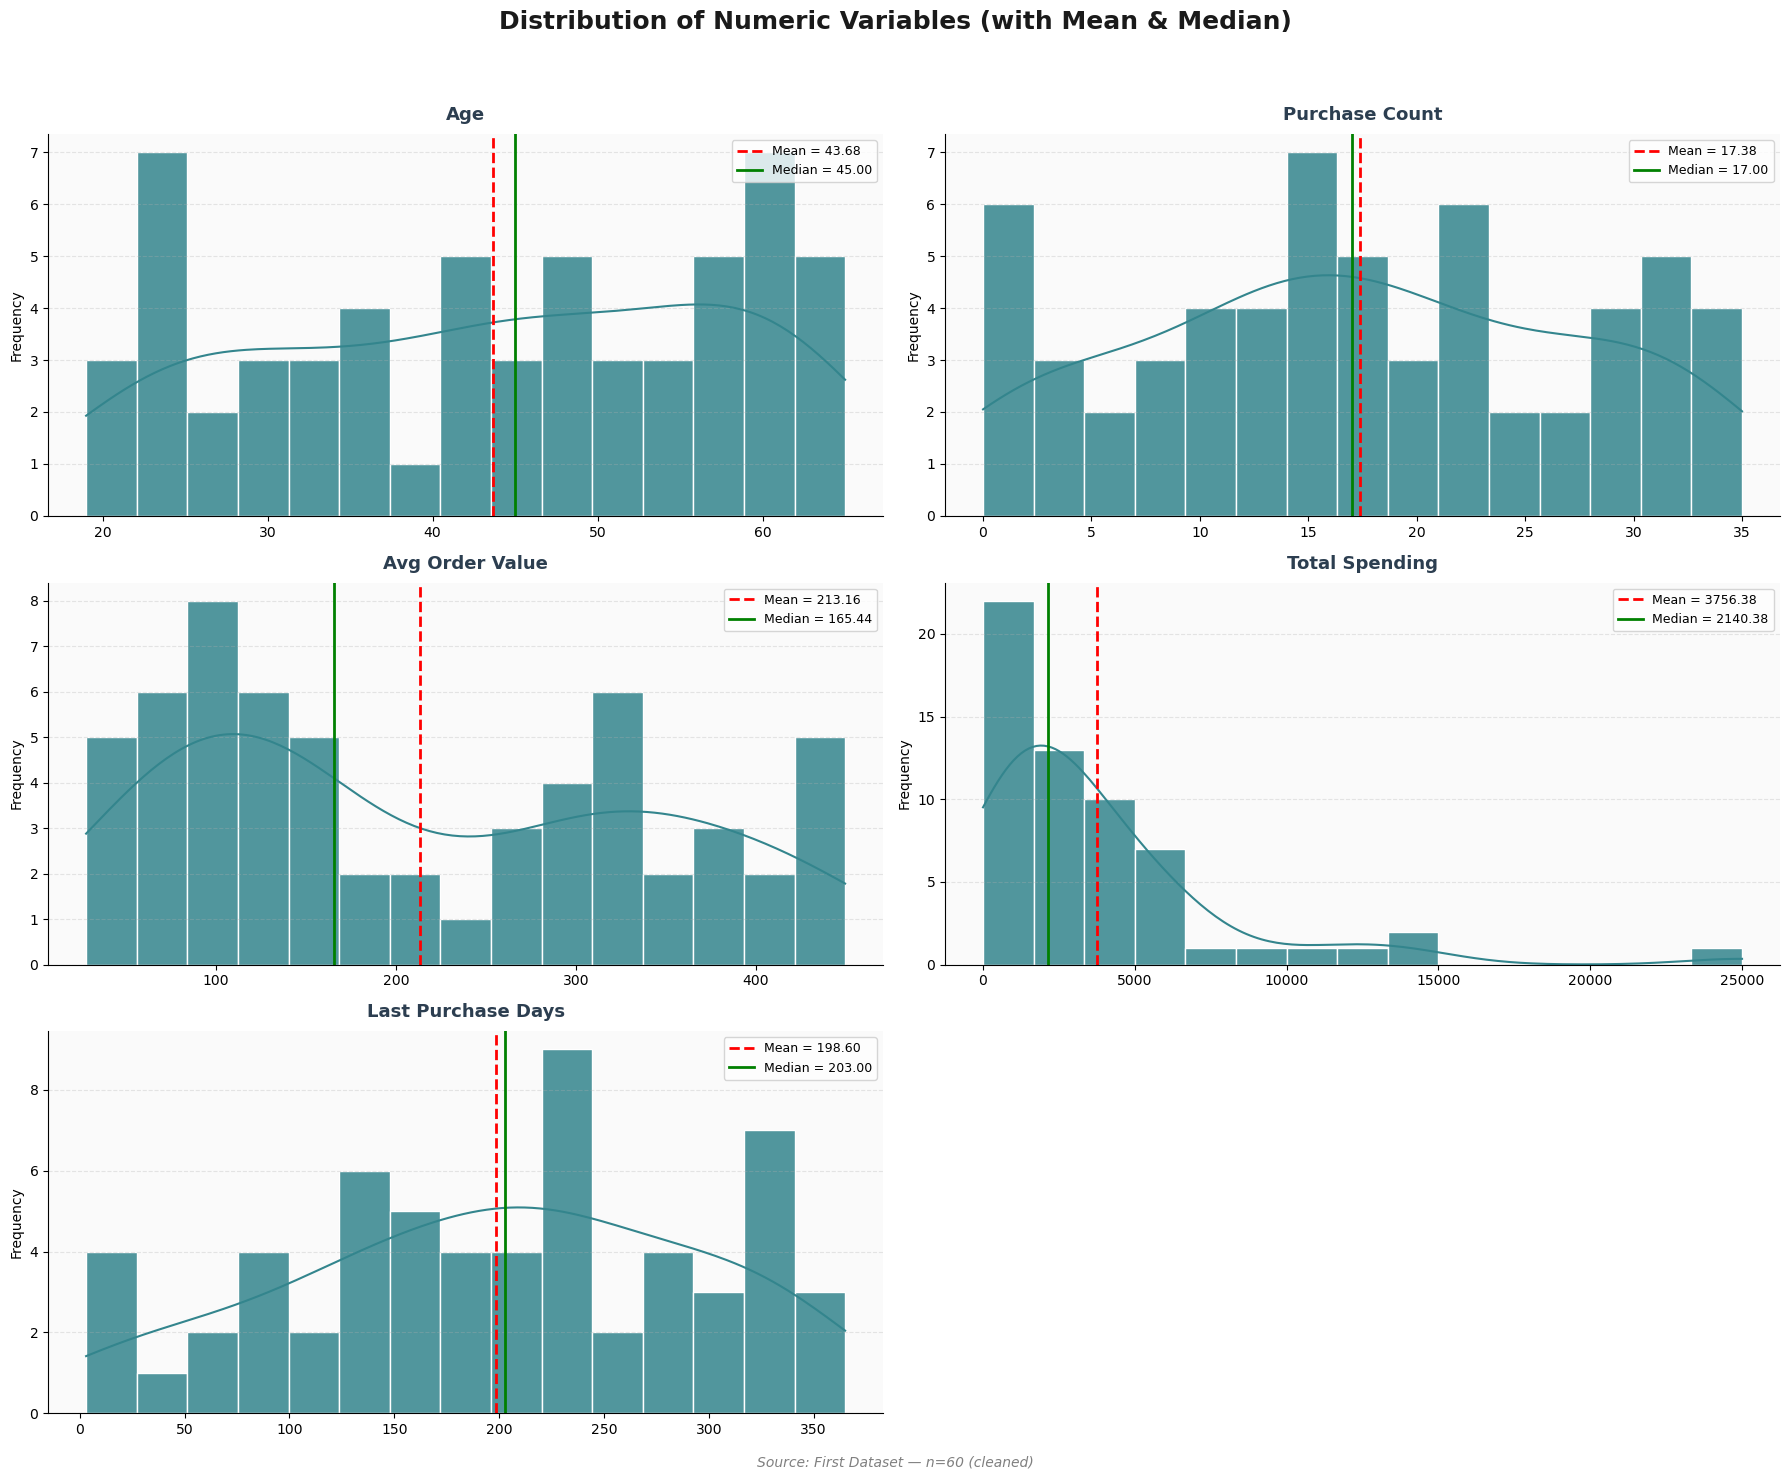

In [53]:
numeric_cols = ['age', 'purchase_count', 'avg_order_value', 'total_spending',
                'last_purchase_days']

df_num = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    data = df_num[col].dropna()
    mean_val = data.mean()
    median_val = data.median()
    
    sns.histplot(data, bins=15, kde=True, ax=axes[i],
                 color=sns.color_palette('crest', 1)[0],
                 edgecolor='white', alpha=0.85)
    
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2,
                    label=f'Mean = {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2,
                    label=f'Median = {median_val:.2f}')
    
    axes[i].set_title(col.replace('_', ' ').title(),
                      fontsize=13, fontweight='bold', color='#2c3e50', pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].legend(fontsize=9, frameon=True, loc='upper right')
    
    sns.despine(ax=axes[i])
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')
    axes[i].set_facecolor('#fafafa')

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribution of Numeric Variables (with Mean & Median)',
             fontsize=18, fontweight='bold', color='#1a1a1a', y=1.03)
fig.text(0.5, -0.01, 'Source: First Dataset — n=60 (cleaned)',
         ha='center', fontsize=10, style='italic', color='gray')

plt.tight_layout()
plt.savefig('numeric_histograms_pro.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


In [89]:
df.describe()

,customer_id,age,signup_date,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items
count,61.000000,60.000000,61,61.000000,61.000000,60.000000,61.000000,61.000000
mean,1030.229508,45.200000,2023-01-31 22:25:34.426229504,17.606557,211.435738,3749.667333,196.934426,4.196721
min,1001.000000,19.000000,2021-02-23 00:00:00,0.000000,27.630000,0.000000,3.000000,0.000000
25%,1015.000000,31.750000,2021-12-16 00:00:00,11.000000,108.190000,1167.035000,132.000000,2.000000
50%,1030.000000,45.000000,2022-08-19 00:00:00,17.000000,161.330000,2188.865000,201.000000,4.000000
75%,1045.000000,58.000000,2024-06-11 00:00:00,26.000000,323.320000,4692.150000,273.000000,7.000000
max,1060.000000,145.000000,2025-09-09 00:00:00,35.000000,449.810000,25000.000000,365.000000,8.000000
std,17.446483,19.167239,NaN,10.214824,130.113726,4262.248522,97.892436,2.663454


## Numerical Variables — Distribution Analysis

###  Observed Distributions

| Variable | Shape | Interpretation |
|---|---|---|
| Age | Approximately Normal | Symmetric spread; mean ≈ median |
| Avg Order Value | Approximately Normal | Centered distribution; minor skew |
| Last Purchase Days | Approximately Normal | Consistent recency pattern |
| Total Spending | Right-skewed (Exponential-like) | Few high-value customers dominate |
| Purchase Count | Slightly skewed | Moderate variance |

### Statistical Insight

Based on the **Law of Large Numbers**, as sample size increases:

- `Age`, `Avg Order Value`, and `Last Purchase Days` are expected to converge
  to a Normal distribution — their current symmetric shape supports this.
- `Total Spending` exhibits a **right-skewed / exponential-like** distribution,
  consistent with the Pareto principle: a small segment of customers
  contributes disproportionately to total revenue.

> **Note:** With n=60, normality assumptions should be validated via
> Shapiro-Wilk or Q-Q plots before applying parametric tests.


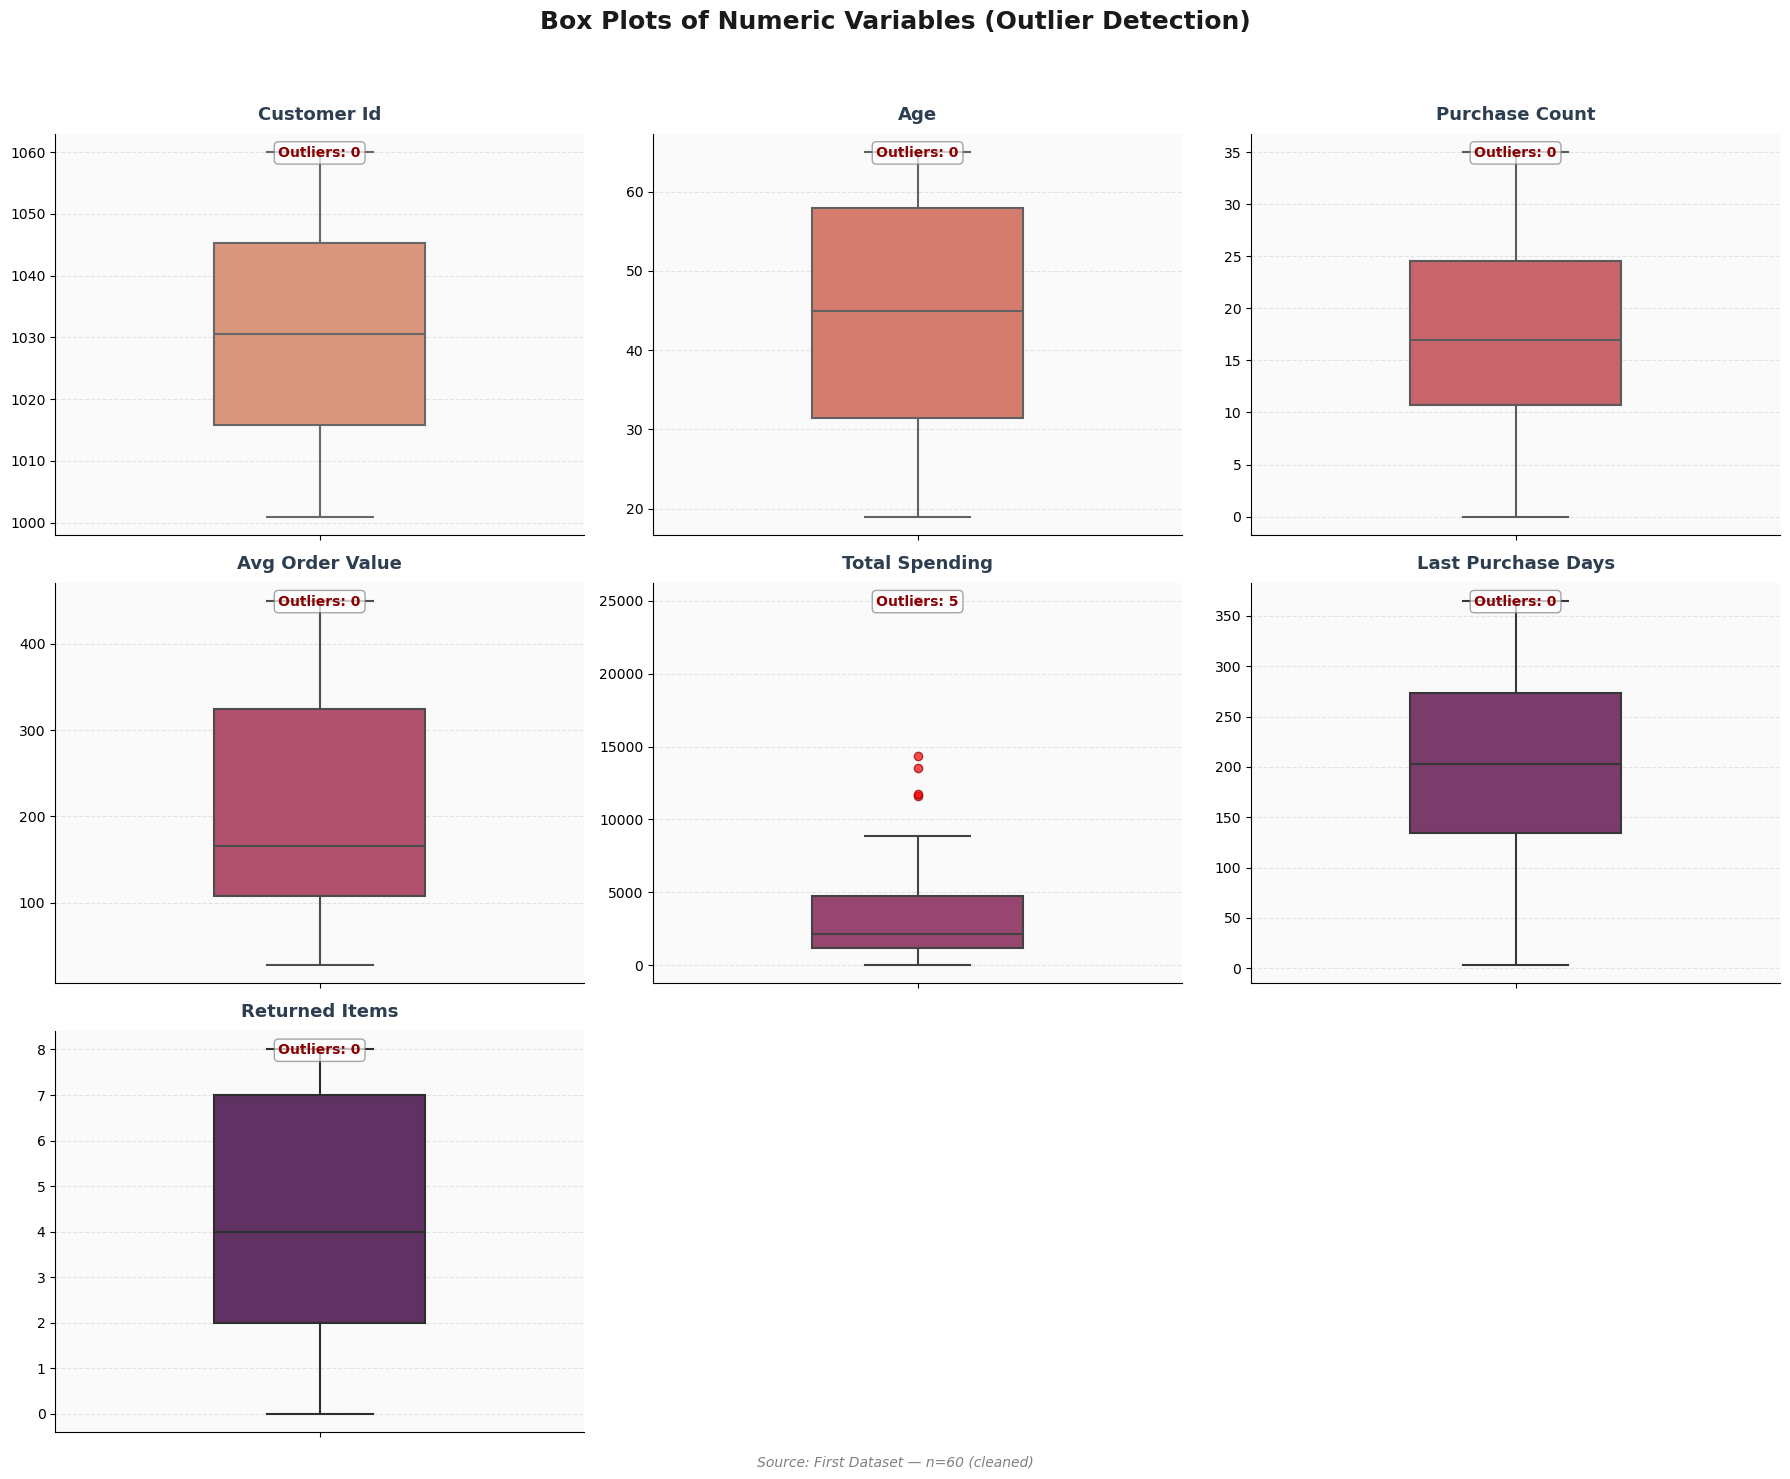

In [59]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

numeric_cols = df.select_dtypes(include='number').columns.tolist()

box_palette = sns.color_palette('flare', len(numeric_cols))

for i, (col, color) in enumerate(zip(numeric_cols, box_palette)):
    data = df[col].dropna()
    
    sns.boxplot(y=data, ax=axes[i], color=color, width=0.4,
                fliersize=6, linewidth=1.5,
                flierprops=dict(marker='o', markerfacecolor='red',
                                 markeredgecolor='darkred', markersize=6, alpha=0.7))
    
    axes[i].set_title(col.replace('_', ' ').title(),
                       fontsize=13, fontweight='bold', color='#2c3e50', pad=10)
    axes[i].set_ylabel('')
    
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    axes[i].text(0.5, 0.97, f'Outliers: {n_outliers}',
                 transform=axes[i].transAxes, ha='center', va='top',
                 fontsize=10, fontweight='bold', color='darkred',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='gray'))
    
    sns.despine(ax=axes[i])
    axes[i].grid(axis='y', alpha=0.3, linestyle='--')
    axes[i].set_facecolor('#fafafa')

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Box Plots of Numeric Variables (Outlier Detection)',
             fontsize=18, fontweight='bold', color='#1a1a1a', y=1.03)
fig.text(0.5, -0.01, 'Source: First Dataset — n=60 (cleaned)',
          ha='center', fontsize=10, style='italic', color='gray')

plt.tight_layout()
plt.savefig('numeric_boxplots_pro.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


## Numerical Variables — Boxplot Analysis

### Visual Overview

The boxplots below display the spread, central tendency, and outlier behavior
of all five numerical variables in the dataset (n=60).

---

### Variable-by-Variable Interpretation

**Age**
- Symmetric distribution with IQR roughly between 28 ,48.
- Median centered near 38; no significant outliers.
- Consistent with a near-normal distribution - supports LLN convergence
  hypothesis as sample grows.

**Avg Order Value**
- Balanced spread; median near the center of the box.
- Minor upper whisker extension suggests slight positive skew, but overall
  symmetric enough to treat as approximately normal.
- Suitable for parametric analysis after Shapiro-Wilk validation.

**Last Purchase Days**
- Compact IQR with a few high-end outliers (customers inactive for longer
  periods).
- Median recency is moderate; outliers may represent churned customers worth
  flagging for retention analysis.

**Total Spending**
- Pronounced right skew: long upper whisker and multiple high-value outliers.
- Consistent with an exponential-like / Pareto distribution - a small segment
  of customers drives disproportionate revenue.
- Log transformation recommended before applying parametric models.

**Purchase Count**
- Moderate spread; slight right skew visible from whisker asymmetry.
- Outliers on the upper end indicate a small group of highly active buyers.

---

### Key Takeaways

| Variable | Shape | Outliers | Recommended Action |
|---|---|---|---|
| Age | ~Normal | None | Ready for parametric use |
| Avg Order Value | ~Normal | Minor | Validate with Shapiro-Wilk |
| Last Purchase Days | ~Normal | A few high | Flag as potential churned users |
| Total Spending | Right-skewed | Several high | Apply log transformation |
| Purchase Count | Slight right skew | A few high | Investigate high-frequency buyers |

> **Statistical Note:** With n=60, normality cannot be assumed solely from
> visual inspection. Apply Shapiro-Wilk ($p > 0.05$) or Q-Q plots before
> using parametric tests on any variable.
`


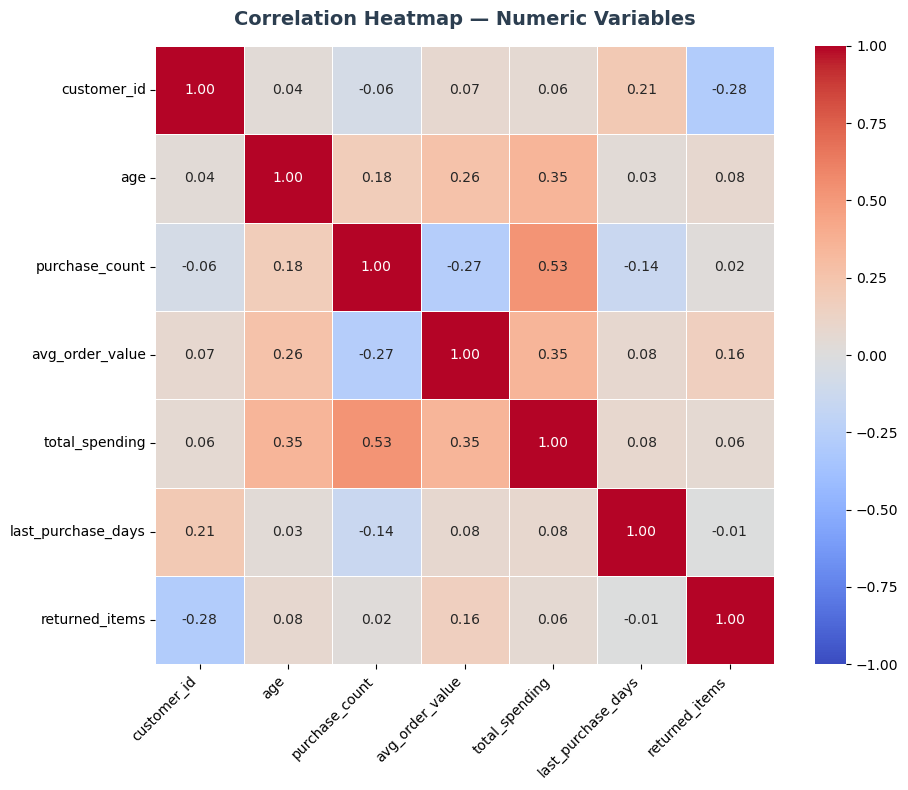

In [107]:


numeric_cols = df.select_dtypes(include='number').columns.tolist()

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 10},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation Heatmap — Numeric Variables',
             fontsize=14, fontweight='bold', color='#2c3e50', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


## Correlation Analysis

### Overview

This heatmap shows Pearson correlation coefficients across all seven numerical variables, including `customer_id` (excluded from interpretation since it's an identifier, not a measurable feature).

### Correlation Matrix Summary

| Pair | Coefficient | Strength |
|---|---|---|
| `purchase_count` ↔ `total_spending` | **0.53** | Moderate positive |
| `age` ↔ `total_spending` | 0.35 | Weak-moderate positive |
| `avg_order_value` ↔ `total_spending` | 0.35 | Weak-moderate positive |
| `purchase_count` ↔ `avg_order_value` | -0.27 | Weak negative |
| `age` ↔ `avg_order_value` | 0.26 | Weak positive |
| `age` ↔ `purchase_count` | 0.18 | Very weak positive |
| `avg_order_value` ↔ `returned_items` | 0.16 | Very weak positive |
| `purchase_count` ↔ `last_purchase_days` | -0.14 | Very weak negative |
| Others (age–last_purchase_days, total_spending–returned_items, etc.) | ≈ 0.00–0.08 | Negligible |

### Strongest Relationship

None of the correlations reach a strong threshold ($|r| > 0.7$), but the clear standout is:

**`purchase_count` and `total_spending` ($r = 0.53$)** — customers who buy more often naturally accumulate higher total spending. It's the only pair reaching "moderate" strength and has a coherent business/causal story (frequency drives volume).

Runner-up candidates, both at $r = 0.35$:
- `age` ↔ `total_spending` — older customers may have more purchasing power.
- `avg_order_value` ↔ `total_spending` — partially a mathematical artifact, since `total_spending` ≈ `purchase_count` × `avg_order_value`.

### Key Findings

- **`purchase_count` ↔ `avg_order_value` = -0.27**: suggests two distinct customer archetypes — frequent low-ticket buyers vs. occasional big-ticket buyers. Good candidate for **customer segmentation** (e.g., K-means, RFM) rather than regression.
- **`returned_items` correlates weakly with everything** (max 0.16 with `avg_order_value`), implying returns are driven by factors *not captured* in the numeric data (e.g., product category, satisfaction score).
- **`last_purchase_days` is essentially uncorrelated with all other variables** — churn risk can't be predicted from spending patterns alone; behavioral/satisfaction data would be needed.
- **Multicollinearity caution**: `total_spending` is mathematically derived from `purchase_count` and `avg_order_value`, so using all three together in a regression model would violate the independence assumption.

### Modeling Recommendation

1. Use `purchase_count` as a predictor for `total_spending` (the only defensible linear pair).
2. Treat `avg_order_value` vs `purchase_count` as a **segmentation feature**, not a regression target.
3. Bring in categorical variables (satisfaction, tier, city) as covariates — numeric-only correlations here are too weak to stand alone.
